In [1]:
import requests
import pandas as pd
from io import StringIO

FLOW = "OECD.ELS.HD,DSD_SHA@DF_SHA"
BASE = "https://sdmx.oecd.org/public/rest/data"

def build_dq(  
    ref_area,
    freq="A",
    measure="EXP_HEALTH",
    unit_measure="USD_PPP_PS",  
    financing_scheme="",        
    financing_scheme_rev="",    
    function="HC3",             
    mode_provision="",
    provider="",
    factor_provision="",
    asset_type="",
    price_base="",
):
    parts = [
        ref_area, freq, measure, unit_measure,
        financing_scheme, financing_scheme_rev, function,
        mode_provision, provider, factor_provision, asset_type, price_base
    ]
    return ".".join(parts)

countries = "USA+CAN+GBR+JPN+CHN"

dq = build_dq(
    ref_area=countries,
    freq="A",
    measure="EXP_HEALTH",
    unit_measure="USD_PPP_PS",  
    function="HC3",     
)

params = {
    "startPeriod": "2020",
    "endPeriod": "2024",
    "dimensionAtObservation": "AllDimensions",
    "format": "csvfilewithlabels",
}

url = f"{BASE}/{FLOW}/{dq}"
resp = requests.get(url, params=params)

if resp.status_code != 200:
    print("Status:", resp.status_code)
    print("URL:", resp.url)
    print("First 800 chars of response:\n", resp.text[:800])
    resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text))

df_oop = df[
    (df["Financing scheme"] == "Household out-of-pocket payments") &
    (df["TIME_PERIOD"].between(2020, 2024))
].copy()

df_oop_pc = df_oop[
    df_oop["Unit of measure"].str.contains("capita|person", case=False, na=False)
].copy()

oop_table = (
    df_oop_pc[["REF_AREA", "TIME_PERIOD", "Unit of measure", "OBS_VALUE"]]
    .rename(columns={"REF_AREA": "country", "TIME_PERIOD": "year", "OBS_VALUE": "value"})
    .sort_values(["country", "year"])
)

print("Countries returned:", sorted(df["REF_AREA"].unique()))
print("Years returned:", sorted(df["TIME_PERIOD"].unique()))
print(oop_table.head(25))

Countries returned: ['CAN', 'GBR', 'JPN', 'USA']
Years returned: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
     country  year                       Unit of measure    value
689      CAN  2020  US dollars per person, PPP converted  246.715
739      CAN  2020  US dollars per person, PPP converted    0.678
807      CAN  2020  US dollars per person, PPP converted    6.406
844      CAN  2020  US dollars per person, PPP converted    6.406
893      CAN  2020  US dollars per person, PPP converted  239.631
922      CAN  2020  US dollars per person, PPP converted  239.631
1354     CAN  2020  US dollars per person, PPP converted  246.715
1378     CAN  2020  US dollars per person, PPP converted    0.678
649      CAN  2021  US dollars per person, PPP converted  266.460
684      CAN  2021  US dollars per person, PPP converted  252.060
742      CAN  2021  US dollars per person, PPP converted    0.650
782      CAN  2021  US dollars per person, PPP converted    0.

In [2]:
print(df[df["REF_AREA"]=="CHN"].shape)

(0, 46)


In [3]:
print(df[df["REF_AREA"].isin(["USA","GBR","JPN"])][["REF_AREA","Financing scheme"]].drop_duplicates().head(30))


     REF_AREA                                   Financing scheme
0         USA                                              Total
65        USA               Compulsory private insurance schemes
66        USA                   Household out-of-pocket payments
67        USA   Compulsory contributory health insurance schemes
68        USA               Voluntary healthcare payment schemes
69        USA  Voluntary schemes/household out-of-pocket paym...
70        USA                    Social health insurance schemes
71        USA                      Government/compulsory schemes
72        USA                                 Government schemes
280       GBR                                              Total
412       GBR                      Government/compulsory schemes
413       GBR                                 Government schemes
414       GBR  Voluntary schemes/household out-of-pocket paym...
415       GBR               Voluntary healthcare payment schemes
416       GBR            

In [4]:
df_oop_all = df[
    (df["Financing scheme"] == "Household out-of-pocket payments") &
    (df["TIME_PERIOD"].between(2020, 2024))
].copy()

print(df_oop_all.groupby("REF_AREA")["Unit of measure"].unique())

REF_AREA
CAN    [US dollars per person, PPP converted]
GBR    [US dollars per person, PPP converted]
JPN    [US dollars per person, PPP converted]
USA    [US dollars per person, PPP converted]
Name: Unit of measure, dtype: object


In [5]:
df_oop = df[
    (df["Financing scheme"] == "Household out-of-pocket payments") &
    (df["TIME_PERIOD"].between(2020, 2024)) &
    (df["Unit of measure"] == "US dollars per person, PPP converted")
].copy()

print("After basic filters:", sorted(df_oop["REF_AREA"].unique()), "rows:", len(df_oop))

total_code = "_T"

for col in ["FUNCTION", "MODE_PROVISION", "PROVIDER", "FACTOR_PROVISION", "ASSET_TYPE", "PRICE_BASE"]:
    if col in df_oop.columns:
        before = len(df_oop)
        df_oop = df_oop[df_oop[col].astype(str).str.strip().eq(total_code)]
        print(f"After restricting {col} to _T:", sorted(df_oop['REF_AREA'].unique()), "rows:", len(df_oop), f"(dropped {before-len(df_oop)})")

oop_country_year = (
    df_oop.groupby(["REF_AREA", "TIME_PERIOD"], as_index=False)["OBS_VALUE"]
    .mean()  
    .rename(columns={"REF_AREA": "country", "TIME_PERIOD": "year", "OBS_VALUE": "oop_per_person_ppp"})
    .sort_values(["country", "year"])
)

print(oop_country_year)

After basic filters: ['CAN', 'GBR', 'JPN', 'USA'] rows: 120
After restricting FUNCTION to _T: [] rows: 0 (dropped 120)
After restricting MODE_PROVISION to _T: [] rows: 0 (dropped 0)
After restricting PROVIDER to _T: [] rows: 0 (dropped 0)
After restricting FACTOR_PROVISION to _T: [] rows: 0 (dropped 0)
After restricting ASSET_TYPE to _T: [] rows: 0 (dropped 0)
After restricting PRICE_BASE to _T: [] rows: 0 (dropped 0)
Empty DataFrame
Columns: [country, year, oop_per_person_ppp]
Index: []


In [6]:
funcs = (
    df_oop[["FUNCTION", "Health function"]]
    .drop_duplicates()
    .sort_values(["FUNCTION"])
)

print(funcs.head(50))
print("Total-like rows:")
print(funcs[funcs["Health function"].str.contains("total", case=False, na=False)])

Empty DataFrame
Columns: [FUNCTION, Health function]
Index: []
Total-like rows:
Empty DataFrame
Columns: [FUNCTION, Health function]
Index: []


In [7]:
nuniq = df_oop.groupby(["REF_AREA", "TIME_PERIOD"])["OBS_VALUE"].nunique()
print(nuniq.head(20))
print("Unique-value counts summary:")
print(nuniq.describe())

Series([], Name: OBS_VALUE, dtype: int64)
Unique-value counts summary:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: OBS_VALUE, dtype: float64


In [8]:
print(df_oop.groupby(["REF_AREA","TIME_PERIOD"])["OBS_VALUE"].nunique().head(20))

Series([], Name: OBS_VALUE, dtype: int64)


In [9]:
# 1) Quick sanity check on what came back
print("Returned countries:", sorted(df["REF_AREA"].dropna().unique()))
print("Returned years:", sorted(df["TIME_PERIOD"].dropna().unique())[:10], "...")

# 2) What financing scheme labels exist?
schemes = (
    df[["FINANCING_SCHEME", "Financing scheme"]]
    .drop_duplicates()
    .sort_values(["Financing scheme"])
)
print("\nFinancing scheme labels containing 'out-of-pocket':")
print(schemes[schemes["Financing scheme"].astype(str).str.contains("out-of-pocket", case=False, na=False)].head(30))

# 3) What unit labels exist?
units = (
    df[["UNIT_MEASURE", "Unit of measure"]]
    .drop_duplicates()
    .sort_values(["Unit of measure"])
)
print("\nUnit labels containing 'PPP' and 'person/capita':")
print(units[
    units["Unit of measure"].astype(str).str.contains("PPP", case=False, na=False) &
    units["Unit of measure"].astype(str).str.contains("person|capita", case=False, na=False)
].head(30))

# 4) Build df_oop using CONTAINS matching 
df_oop = df[
    df["Financing scheme"].astype(str).str.contains("out-of-pocket", case=False, na=False) &
    df["Unit of measure"].astype(str).str.contains("PPP", case=False, na=False) &
    df["Unit of measure"].astype(str).str.contains("person|capita", case=False, na=False) &
    df["TIME_PERIOD"].between(2020, 2024)
].copy()

print("\ndf_oop rows:", len(df_oop))
if len(df_oop) > 0:
    print("df_oop countries:", sorted(df_oop["REF_AREA"].unique()))
    print(df_oop[["REF_AREA","TIME_PERIOD","Financing scheme","Unit of measure","OBS_VALUE"]].head(20))

    # 5) Now the nunique check will work
    print("\nDistinct values per country-year (first 20 groups):")
    print(df_oop.groupby(["REF_AREA","TIME_PERIOD"])["OBS_VALUE"].nunique().head(20))
else:
    print("\nStill empty -> the dataset slice you downloaded does not contain PPP per-person out-of-pocket rows for 2020–2024.")
    print("In that case, we should wildcard UNIT_MEASURE in the SDMX key and re-download, then choose the unit that exists.")

Returned countries: ['CAN', 'GBR', 'JPN', 'USA']
Returned years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)] ...

Financing scheme labels containing 'out-of-pocket':
     FINANCING_SCHEME                                   Financing scheme
66                HF3                   Household out-of-pocket payments
1835             HF31               Out-of-pocket excluding cost-sharing
69             HF2HF3  Voluntary schemes/household out-of-pocket paym...

Unit labels containing 'PPP' and 'person/capita':
  UNIT_MEASURE                       Unit of measure
0   USD_PPP_PS  US dollars per person, PPP converted

df_oop rows: 260
df_oop countries: ['CAN', 'GBR', 'JPN', 'USA']
    REF_AREA  TIME_PERIOD                                   Financing scheme  \
66       USA         2020                   Household out-of-pocket payments   
69       USA         2020  Voluntary schemes/household out-of-pocket paym...   
76       USA         2021  Voluntary scheme

In [10]:
probe_dq = build_dq(ref_area="CHN", freq="A", measure="EXP_HEALTH", unit_measure="", function="",)

probe_params = {"startPeriod": "2020", "endPeriod": "2024", "dimensionAtObservation": "AllDimensions", "format": "csvfilewithlabels",}

probe_url = f"{BASE}/{FLOW}/{probe_dq}"
probe_resp = requests.get(probe_url, params=probe_params)
probe_resp.raise_for_status()

probe_df = pd.read_csv(StringIO(probe_resp.text))

print("CHN probe rows:", len(probe_df))
if len(probe_df) > 0:
    print("CHN units:", sorted(probe_df["Unit of measure"].dropna().unique())[:50])
    print("CHN years:", sorted(probe_df["TIME_PERIOD"].dropna().unique()))
    print("CHN financing schemes (sample):", sorted(probe_df["Financing scheme"].dropna().unique())[:30])

CHN probe rows: 504
CHN units: ['Euros per person, PPP converted', 'Euros, PPP converted', 'National currency', 'National currency per person', 'Percentage of GDP', 'Percentage of expenditure on health', 'US dollars per person, PPP converted', 'US dollars, PPP converted']
CHN years: [np.int64(2020), np.int64(2021), np.int64(2022)]
CHN financing schemes (sample): ['Compulsory contributory health insurance schemes', 'Enterprise financing schemes', 'Government schemes', 'Government/compulsory schemes', 'Household out-of-pocket payments', 'NPISH financing schemes', 'Rest of the world financing schemes (non-resident)', 'Social health insurance schemes', 'Total', 'Voluntary health insurance schemes', 'Voluntary healthcare payment schemes', 'Voluntary schemes/household out-of-pocket payments']


In [11]:
import requests
import pandas as pd
from io import StringIO

FLOW = "OECD.ELS.HD,DSD_SHA@DF_SHA"
BASE = "https://sdmx.oecd.org/public/rest/data"

def build_dq(
    ref_area,
    freq="A",
    measure="EXP_HEALTH",
    unit_measure="",          
    financing_scheme="",
    financing_scheme_rev="",
    function="HC3",
    mode_provision="",
    provider="",
    factor_provision="",
    asset_type="",
    price_base="",
):
    parts = [ref_area, freq, measure, unit_measure, financing_scheme, financing_scheme_rev, function, mode_provision, provider, factor_provision, asset_type, price_base]
    return ".".join(parts)

countries = "USA+CAN+GBR+JPN+CHN"

dq = build_dq(ref_area=countries, freq="A", measure="EXP_HEALTH", unit_measure="", function="HC3",)

params = {"startPeriod": "2015", "endPeriod": "2022", "dimensionAtObservation": "AllDimensions", "format": "csvfilewithlabels",}

url = f"{BASE}/{FLOW}/{dq}"
resp = requests.get(url, params=params)

if resp.status_code != 200:
    print("Status:", resp.status_code)
    print("URL:", resp.url)
    print("First 800 chars of response:\n", resp.text[:800])
    resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text))

print("\n=== DEBUG: Request URL (final) ===")
print(resp.url)

print("\n=== DEBUG: Returned REF_AREA codes ===")
print(sorted(df["REF_AREA"].dropna().unique()))

print("\n=== DEBUG: Counts by REF_AREA ===")
print(df["REF_AREA"].value_counts(dropna=False))

print("\n=== DEBUG: Any CHN rows? ===")
print((df["REF_AREA"] == "CHN").any())

TARGET_FIN = "Household out-of-pocket payments"
TARGET_UNIT = "US dollars per person, PPP converted"

df_oop = df[(df["Financing scheme"] == TARGET_FIN) & (df["Unit of measure"] == TARGET_UNIT) & (df["TIME_PERIOD"].between(2015, 2022))].copy()

print("\n=== DEBUG: Countries after OOP+unit+year filters ===")
print(sorted(df_oop["REF_AREA"].dropna().unique()))
print("Rows after filters:", len(df_oop))

oop_table = (
    df_oop[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]
    .rename(columns={"REF_AREA": "country", "TIME_PERIOD": "year", "OBS_VALUE": "value"})
    .sort_values(["country", "year"])
)

oop_pivot = (
    oop_table
    .pivot_table(index="year", columns="country", values="value", aggfunc="mean")
    .sort_index()
)

print("\nOut-of-pocket spending per person (PPP), HC3 (2015–2022)")
print(oop_pivot)



=== DEBUG: Request URL (final) ===
https://sdmx.oecd.org/public/rest/data/OECD.ELS.HD,DSD_SHA@DF_SHA/USA+CAN+GBR+JPN+CHN.A.EXP_HEALTH....HC3.....?startPeriod=2015&endPeriod=2022&dimensionAtObservation=AllDimensions&format=csvfilewithlabels

=== DEBUG: Returned REF_AREA codes ===
['CAN', 'GBR', 'JPN', 'USA']

=== DEBUG: Counts by REF_AREA ===
REF_AREA
CAN    11321
JPN     8050
GBR     6227
USA     4688
Name: count, dtype: int64

=== DEBUG: Any CHN rows? ===
False

=== DEBUG: Countries after OOP+unit+year filters ===
['CAN', 'GBR', 'JPN', 'USA']
Rows after filters: 224

Out-of-pocket spending per person (PPP), HC3 (2015–2022)
country         CAN         GBR        JPN         USA
year                                                  
2015      81.152625  160.387333  29.848500  105.681167
2016      87.156125  162.612500  32.670125  111.515500
2017     103.385625  168.519167  33.205125  109.921167
2018     110.895500  171.683667  35.464375  115.361500
2019     116.429875  179.742667  35.5

In [12]:
import requests
import pandas as pd
from io import StringIO

FLOW = "OECD.ELS.HD,DSD_SHA@DF_SHA"
BASE = "https://sdmx.oecd.org/public/rest/data"

def build_dq(
    ref_area,
    freq="A",
    measure="EXP_HEALTH",
    unit_measure="",         
    financing_scheme="",
    financing_scheme_rev="",
    function="",           
    mode_provision="",
    provider="",
    factor_provision="",
    asset_type="",
    price_base="",
):
    parts = [
        ref_area, freq, measure, unit_measure,
        financing_scheme, financing_scheme_rev, function,
        mode_provision, provider, factor_provision, asset_type, price_base
    ]
    return ".".join(parts)

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

countries = "USA+CAN+GBR+JPN+CHN"

dq = build_dq(ref_area=countries, freq="A", measure="EXP_HEALTH", unit_measure="", function="",)

params = {"startPeriod": "2015", "endPeriod": "2022", "dimensionAtObservation": "AllDimensions", "format": "csvfilewithlabels",}

url = f"{BASE}/{FLOW}/{dq}"
resp = requests.get(url, params=params)

if resp.status_code != 200:
    print("Status:", resp.status_code)
    print("URL:", resp.url)
    print("First 800 chars of response:\n", resp.text[:800])
    resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text))

print("\n=== DEBUG: Request URL (final) ===")
print(resp.url)

print("\n=== DEBUG: Returned REF_AREA codes ===")
print(sorted(df["REF_AREA"].dropna().unique()))

print("\n=== DEBUG: Any CHN rows? ===")
print((df["REF_AREA"] == "CHN").any())

TARGET_FIN = "Household out-of-pocket payments"
TARGET_UNIT = "US dollars per person, PPP converted"

function_col = first_existing_col(df, ["Function", "Health care function", "Function of health care"])

total_dim_candidates = ["Mode of provision", "Provider", "Factor of provision", "Asset type", "Price base", "Financing scheme (revised)",]

df_f = df[(df["Financing scheme"] == TARGET_FIN) & (df["Unit of measure"] == TARGET_UNIT) & (df["TIME_PERIOD"].between(2015, 2022))].copy()

if function_col is not None:

    funcs = set(df_f[function_col].dropna().unique())
    if "Total" in funcs:
        df_f = df_f[df_f[function_col] == "Total"].copy()
    else:
        df_f = df_f[df_f[function_col].astype(str).str.contains(r"\(HC\)|Current expenditure on health|Total", regex=True, na=False)].copy()
else:
    print("\nWARNING: Could not find a function column. Proceeding without function filtering (may include multiple functions).")

for col in total_dim_candidates:
    if col in df_f.columns:
        df_f = df_f[(df_f[col].isna()) | (df_f[col] == "Total")].copy()

print("\n=== DEBUG: Countries after filters ===")
print(sorted(df_f["REF_AREA"].dropna().unique()))
print("Rows after filters:", len(df_f))

oop_table = (df_f[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]] .rename(columns={"REF_AREA": "country", "TIME_PERIOD": "year", "OBS_VALUE": "value"}) .sort_values(["country", "year"]))


dup_counts = oop_table.groupby(["country", "year"]).size()
if (dup_counts > 1).any():
    print("\nNOTE: Duplicate rows remain after filtering; aggregating by mean for (country, year).")
    oop_table = oop_table.groupby(["country", "year"], as_index=False)["value"].mean()

oop_pivot = oop_table.pivot(index="year", columns="country", values="value").sort_index()

print("\nOut-of-pocket spending per person (PPP), 2015–2022")
print(oop_pivot)

C:\Users\huynh\AppData\Local\Temp\ipykernel_17080\2382739098.py:50: DtypeWarning: Columns (36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(resp.text))



=== DEBUG: Request URL (final) ===
https://sdmx.oecd.org/public/rest/data/OECD.ELS.HD,DSD_SHA@DF_SHA/USA+CAN+GBR+JPN+CHN.A.EXP_HEALTH.........?startPeriod=2015&endPeriod=2022&dimensionAtObservation=AllDimensions&format=csvfilewithlabels

=== DEBUG: Returned REF_AREA codes ===
['CAN', 'CHN', 'GBR', 'JPN', 'USA']

=== DEBUG: Any CHN rows? ===
True


=== DEBUG: Countries after filters ===
[]
Rows after filters: 0

Out-of-pocket spending per person (PPP), 2015–2022
Empty DataFrame
Columns: []
Index: []


In [13]:
print("""Data from OECD (2015-2022)""")

import requests
import pandas as pd
from io import StringIO

FLOW = "OECD.ELS.HD,DSD_SHA@DF_SHA"
BASE = "https://sdmx.oecd.org/public/rest/data"

def build_dq(
    ref_area,
    freq="A",
    measure="EXP_HEALTH",
    unit_measure="",      
    financing_scheme="",
    financing_scheme_rev="",
    function="",           
    mode_provision="",
    provider="",
    factor_provision="",
    asset_type="",
    price_base="",
):
    parts = [
        ref_area, freq, measure, unit_measure,
        financing_scheme, financing_scheme_rev, function,
        mode_provision, provider, factor_provision, asset_type, price_base
    ]
    return ".".join(parts)

countries = "USA+CAN+GBR+JPN+CHN"

dq = build_dq(
    ref_area=countries,
    freq="A",
    measure="EXP_HEALTH",
    unit_measure="",
    function="",
)

params = {
    "startPeriod": "2015",
    "endPeriod": "2022",
    "dimensionAtObservation": "AllDimensions",
    "format": "csvfilewithlabels",
}

url = f"{BASE}/{FLOW}/{dq}"
resp = requests.get(url, params=params)

if resp.status_code != 200:
    print("Status:", resp.status_code)
    print("URL:", resp.url)
    print("First 800 chars of response:\n", resp.text[:800])
    resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text), low_memory=False)

print("\n=== DEBUG: Request URL (final) ===")
print(resp.url)

print("\n=== DEBUG: Returned REF_AREA codes ===")
print(sorted(df["REF_AREA"].dropna().unique()))

print("\n=== DEBUG: Any CHN rows? ===")
print((df["REF_AREA"] == "CHN").any())

print("\n=== DEBUG: Column names ===")
print(list(df.columns))

fin_col = "Financing scheme" if "Financing scheme" in df.columns else None

unit_col = "Unit of measure" if "Unit of measure" in df.columns else None

if fin_col is None or unit_col is None:
    raise KeyError(f"Expected columns not found. Financing col: {fin_col}, Unit col: {unit_col}")

oop_mask = df[fin_col].astype(str).str.contains(r"out[-\s]?of[-\s]?pocket", case=False, na=False)

unit_mask = (
    df[unit_col].astype(str).str.contains(r"US\s*dollars|USD", case=False, na=False) &
    df[unit_col].astype(str).str.contains(r"PPP", case=False, na=False) &
    df[unit_col].astype(str).str.contains(r"person|capita", case=False, na=False)
)

year_mask = df["TIME_PERIOD"].between(2015, 2022)

df_f = df[oop_mask & unit_mask & year_mask].copy()

print("\n=== DEBUG: Countries after label filters ===")
if len(df_f) == 0:
    print("None (0 rows). Showing what values exist so you can adjust filters:")
    print("\nSample financing scheme values:")
    print(pd.Series(df[fin_col].dropna().unique()).sort_values().head(40).to_string(index=False))
    print("\nSample unit values:")
    print(pd.Series(df[unit_col].dropna().unique()).sort_values().head(40).to_string(index=False))
else:
    print(sorted(df_f["REF_AREA"].dropna().unique()))
print("Rows after filters:", len(df_f))

oop_table = (
    df_f[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]
    .rename(columns={"REF_AREA": "country", "TIME_PERIOD": "year", "OBS_VALUE": "value"})
)

oop_table = oop_table.groupby(["country", "year"], as_index=False)["value"].mean()

oop_pivot = oop_table.pivot(index="year", columns="country", values="value").sort_index()

print("\nOut-of-pocket spending per person (PPP), 2015–2022")
print(oop_pivot)

Data from OECD (2015-2022)

=== DEBUG: Request URL (final) ===
https://sdmx.oecd.org/public/rest/data/OECD.ELS.HD,DSD_SHA@DF_SHA/USA+CAN+GBR+JPN+CHN.A.EXP_HEALTH.........?startPeriod=2015&endPeriod=2022&dimensionAtObservation=AllDimensions&format=csvfilewithlabels

=== DEBUG: Returned REF_AREA codes ===
['CAN', 'CHN', 'GBR', 'JPN', 'USA']

=== DEBUG: Any CHN rows? ===
True

=== DEBUG: Column names ===
['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA', 'Reference area', 'FREQ', 'Frequency of observation', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure', 'FINANCING_SCHEME', 'Financing scheme', 'FINANCING_SCHEME_REV', 'Revenues of financing schemes', 'FUNCTION', 'Health function', 'MODE_PROVISION', 'Mode of provision', 'PROVIDER', 'Healthcare provider', 'FACTOR_PROVISION', 'Factor of provision', 'ASSET_TYPE', 'Asset type', 'PRICE_BASE', 'Price base', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'BASE_PER', 'Base period', 'CURRENCY', 'Currency'

In [14]:
import requests
import pandas as pd
from io import StringIO

FLOW = "OECD.ELS.HD,DSD_SHA@DF_SHA"
BASE = "https://sdmx.oecd.org/public/rest/data"

def build_dq(
    ref_area,
    freq="A",
    measure="EXP_HEALTH",
    unit_measure="",          
    financing_scheme="",
    financing_scheme_rev="",
    function="",              
    mode_provision="",
    provider="",
    factor_provision="",
    asset_type="",
    price_base="",
):
    parts = [
        ref_area, freq, measure, unit_measure,
        financing_scheme, financing_scheme_rev, function,
        mode_provision, provider, factor_provision, asset_type, price_base
    ]
    return ".".join(parts)

countries = "USA+CAN+GBR+JPN+CHN"

dq = build_dq(
    ref_area=countries,
    freq="A",
    measure="EXP_HEALTH",
    unit_measure="",
    function="",
)

params = {
    "startPeriod": "2015",
    "endPeriod": "2022",
    "dimensionAtObservation": "AllDimensions",
    "format": "csvfilewithlabels",
}

url = f"{BASE}/{FLOW}/{dq}"
resp = requests.get(url, params=params)
resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text), low_memory=False)

print("\n=== DEBUG: Returned REF_AREA codes ===")
print(sorted(df["REF_AREA"].dropna().unique()))

FIN_LABEL = "Household out-of-pocket payments"
UNIT_LABEL = "US dollars per person, PPP converted"

base_mask = (
    df["TIME_PERIOD"].between(2015, 2022)
    & df["Financing scheme"].eq(FIN_LABEL)
    & df["Unit of measure"].eq(UNIT_LABEL)
)

dim_mask = (
    df["Health function"].eq("Total")
    & df["Mode of provision"].eq("Total")
    & df["Healthcare provider"].eq("Total")
    & df["Factor of provision"].eq("Not applicable")
    & df["Asset type"].eq("Not applicable")
    & df["Price base"].eq("Current prices")   
)

df_f = df[base_mask & dim_mask].copy()

print("\n=== DEBUG: Rows after base+dimension filters ===")
print(len(df_f))
print("Countries:", sorted(df_f["REF_AREA"].dropna().unique()))
print("Years:", sorted(df_f["TIME_PERIOD"].dropna().unique()))

if "UNIT_MULT" in df_f.columns:
    print("\n=== DEBUG: UNIT_MULT values ===")
    print(sorted(pd.to_numeric(df_f["UNIT_MULT"], errors="coerce").dropna().unique()))

oop_table = (
    df_f[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]
    .rename(columns={"REF_AREA": "country", "TIME_PERIOD": "year", "OBS_VALUE": "value"})
)

dups = oop_table.groupby(["country", "year"]).size()
if (dups > 1).any():
    print("\nWARNING: Duplicate rows remain for some (country, year). Aggregating by mean.")
    oop_table = oop_table.groupby(["country", "year"], as_index=False)["value"].mean()
else:
    oop_table = oop_table.sort_values(["country", "year"])

oop_pivot = oop_table.pivot(index="year", columns="country", values="value").sort_index()

print("\nOut-of-pocket spending per person (PPP), TOTAL slice, 2015–2022 (Current prices)")
print(oop_pivot)


=== DEBUG: Returned REF_AREA codes ===
['CAN', 'CHN', 'GBR', 'JPN', 'USA']

=== DEBUG: Rows after base+dimension filters ===
40
Countries: ['CAN', 'CHN', 'GBR', 'JPN', 'USA']
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

=== DEBUG: UNIT_MULT values ===
[np.int64(0)]

Out-of-pocket spending per person (PPP), TOTAL slice, 2015–2022 (Current prices)
country       CAN      CHN      GBR      JPN       USA
year                                                  
2015      682.876  224.580  609.713  584.828  1099.619
2016      788.869  241.596  624.745  551.733  1129.568
2017      819.919  278.584  646.502  557.509  1139.034
2018      832.147  304.395  681.954  590.383  1181.493
2019      834.283  334.457  732.794  601.168  1227.472
2020      847.500  358.386  667.766  561.322  1200.940
2021      982.283  381.597  753.328  588.340  1327.816
2022     1028.618  410.913  889.909  667.069  1414.779


Filtered data (2015–2022):
            country  year  out_of_pocket_ppp
33           Canada  2015         701.836594
32           Canada  2016         796.515850
31           Canada  2017         829.487909
30           Canada  2018         844.933612
29           Canada  2019         857.039807
28           Canada  2020         860.176074
27           Canada  2021         998.166399
26           Canada  2022        1057.129067
106           China  2015         227.154909
105           China  2016         245.195160
104           China  2017         265.328207
103           China  2018         291.234069
102           China  2019         323.137353
101           China  2020         348.616549
100           China  2021         372.850645
99            China  2022         424.728178
82            Japan  2015         568.749262
81            Japan  2016         555.867891
80            Japan  2017         558.485528
79            Japan  2018         587.658668
78            Japan  2019   

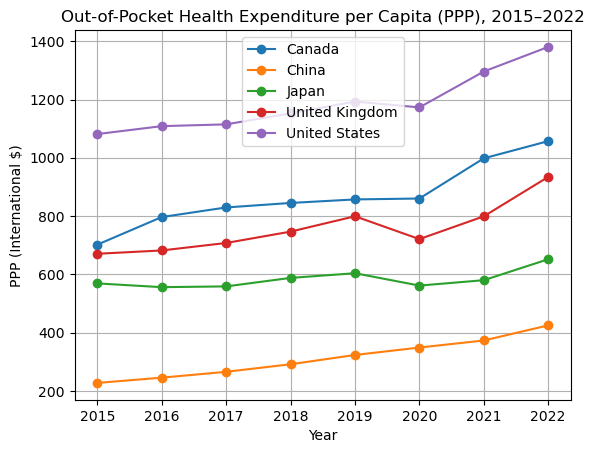

CSV saved as: out_of_pocket_health_expenditure_ppp_2015_2022.csv


In [15]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

countries = {
    "United States": "USA",
    "Canada": "CAN",
    "United Kingdom": "GBR",
    "Japan": "JPN",
    "China": "CHN"
}

indicator = "SH.XPD.OOPC.PP.CD"

base_url = "https://api.worldbank.org/v2/country/{}/indicator/{}?format=json&per_page=5000"

all_data = []

for country_name, country_code in countries.items():
    url = base_url.format(country_code, indicator)
    response = requests.get(url)

    if response.status_code != 200:
        print(f"Error fetching data for {country_name}")
        continue

    json_data = response.json()

    if len(json_data) < 2 or json_data[1] is None:
        print(f"No data available for {country_name}")
        continue

    for entry in json_data[1]:
        if entry["value"] is not None:
            all_data.append({
                "country": country_name,
                "year": int(entry["date"]),
                "out_of_pocket_ppp": entry["value"]
            })

df = pd.DataFrame(all_data)
df = df.sort_values(by=["country", "year"])

df_2015_2022 = df[(df["year"] >= 2015) & (df["year"] <= 2022)]

print("Filtered data (2015–2022):")
print(df_2015_2022)

plt.figure()

for country in df_2015_2022["country"].unique():
    subset = df_2015_2022[df_2015_2022["country"] == country]
    plt.plot(subset["year"], subset["out_of_pocket_ppp"], marker="o", label=country)

plt.title("Out-of-Pocket Health Expenditure per Capita (PPP), 2015–2022")
plt.xlabel("Year")
plt.ylabel("PPP (International $)")
plt.legend()
plt.grid(True)
plt.show()

df_2015_2022.to_csv("out_of_pocket_health_expenditure_ppp_2015_2022.csv", index=False)

print("CSV saved as: out_of_pocket_health_expenditure_ppp_2015_2022.csv")

In [16]:
oecd_long = (oop_pivot.reset_index().melt(id_vars="year", var_name="country", value_name="oecd_value"))

wb_long = df_2015_2022.rename(columns={"out_of_pocket_ppp": "wb_value"})

compare = pd.merge(oecd_long, wb_long, on=["country", "year"], how="inner")

compare["abs_diff"] = compare["oecd_value"] - compare["wb_value"]
compare["pct_diff"] = (compare["abs_diff"] / compare["wb_value"]) * 100

compare = compare.sort_values(["country", "year"])

print("\nOECD vs World Bank comparison (2015–2022)")
print(compare)

compare_rounded = compare.copy()
compare_rounded[["oecd_value","wb_value","abs_diff","pct_diff"]] = \
    compare_rounded[["oecd_value","wb_value","abs_diff","pct_diff"]].round(2)

print("\nRounded comparison:")
print(compare_rounded)


OECD vs World Bank comparison (2015–2022)
Empty DataFrame
Columns: [year, country, oecd_value, wb_value, abs_diff, pct_diff]
Index: []

Rounded comparison:
Empty DataFrame
Columns: [year, country, oecd_value, wb_value, abs_diff, pct_diff]
Index: []


In [19]:
import pandas as pd

# -----------------------------
# OECD: pivot (codes) → long
# -----------------------------
oecd_long = (oop_pivot.reset_index().melt(id_vars="year", var_name="country_code", value_name="oecd_value"))

# -----------------------------
# World Bank: map names → codes
# -----------------------------
name_to_code = {"United States": "USA", "Canada": "CAN", "United Kingdom": "GBR", "Japan": "JPN", "China": "CHN",}

wb_long = df_2015_2022.copy()
wb_long["country_code"] = wb_long["country"].map(name_to_code)

# Safety check: see if any names didn't map
unmapped = wb_long[wb_long["country_code"].isna()]["country"].unique()
if len(unmapped) > 0:
    print("WARNING: Unmapped WB country names:", unmapped)

wb_long = wb_long.rename(columns={"out_of_pocket_ppp": "wb_value"})[["country_code", "year", "wb_value"]]

# Ensure numeric years
oecd_long["year"] = pd.to_numeric(oecd_long["year"], errors="coerce").astype("Int64")
wb_long["year"] = pd.to_numeric(wb_long["year"], errors="coerce").astype("Int64")

# -----------------------------
# Merge
# -----------------------------
compare = pd.merge(oecd_long, wb_long, on=["country_code", "year"], how="inner")

# -----------------------------
# Differences
# -----------------------------
compare["abs_diff"] = compare["oecd_value"] - compare["wb_value"]
compare["pct_diff"] = (compare["abs_diff"] / compare["wb_value"]) * 100

# Add readable country name
code_to_name = {v: k for k, v in name_to_code.items()}
compare["country"] = compare["country_code"].map(code_to_name)

# Order + round for readability
compare = compare.sort_values(["country_code", "year"])
compare_round = compare.copy()
for c in ["oecd_value", "wb_value", "abs_diff", "pct_diff"]:
    compare_round[c] = compare_round[c].round(2)

# Show results
print("\nOECD vs World Bank comparison (2015–2022)")
print(compare_round[["country_code", "country", "year", "oecd_value", "wb_value", "abs_diff", "pct_diff"]])

# Pivot for quick scanning (% diffs)
pct_pivot = compare_round.pivot(index="year", columns="country_code", values="pct_diff").sort_index()
print("\nPercent difference (OECD - WB) / WB * 100")
print(pct_pivot)

# Save
compare_round.to_csv("oecd_vs_worldbank_oop_2015_2022_comparison.csv", index=False)
print("\nSaved: oecd_vs_worldbank_oop_2015_2022_comparison.csv")



OECD vs World Bank comparison (2015–2022)
   country_code         country  year  oecd_value  wb_value  abs_diff  \
0           CAN          Canada  2015      682.88    701.84    -18.96   
1           CAN          Canada  2016      788.87    796.52     -7.65   
2           CAN          Canada  2017      819.92    829.49     -9.57   
3           CAN          Canada  2018      832.15    844.93    -12.79   
4           CAN          Canada  2019      834.28    857.04    -22.76   
5           CAN          Canada  2020      847.50    860.18    -12.68   
6           CAN          Canada  2021      982.28    998.17    -15.88   
7           CAN          Canada  2022     1028.62   1057.13    -28.51   
8           CHN           China  2015      224.58    227.15     -2.57   
9           CHN           China  2016      241.60    245.20     -3.60   
10          CHN           China  2017      278.58    265.33     13.26   
11          CHN           China  2018      304.40    291.23     13.16   
12      

In [18]:
import requests
import pandas as pd

countries = {
    "United States": "USA",
    "Canada": "CAN",
    "United Kingdom": "GBR",
    "Japan": "JPN",
    "China": "CHN"
}

indicator = "SH.XPD.OOPC.PP.CD"  

data = []

for country_name, country_code in countries.items():
    url = f"https://api.worldbank.org/v2/country/{country_code}/indicator/{indicator}?format=json&per_page=100"
    
    response = requests.get(url)
    json_data = response.json()
    
    if len(json_data) > 1:
        for entry in json_data[1]:
            if entry["value"] is not None:
                data.append({
                    "country": country_name,
                    "year": int(entry["date"]),
                    "oop_per_capita_ppp": entry["value"]
                })

df = pd.DataFrame(data)
df = df.sort_values(["country", "year"])
df.head()

,country,year,oop_per_capita_ppp
48,Canada,2000,399.466813
47,Canada,2001,412.683758
46,Canada,2002,433.827541
45,Canada,2003,441.896399
44,Canada,2004,467.414277


In [20]:
print(df["country"].unique())

['Canada' 'China' 'Japan' 'United Kingdom' 'United States']


In [25]:
import requests
import pandas as pd

countries = {
    "United States": "USA",
    "Canada": "CAN",
    "United Kingdom": "GBR",
    "Japan": "JPN",
    "China": "CHN"
}

indicator = "SH.XPD.OOPC.PP.CD"

data = []

for country_name, country_code in countries.items():
    url = f"https://api.worldbank.org/v2/country/{country_code}/indicator/{indicator}?format=json&per_page=1000"
    
    response = requests.get(url)
    json_data = response.json()
    
    if isinstance(json_data, list) and len(json_data) > 1 and json_data[1] is not None:
        for entry in json_data[1]:
            if entry["value"] is not None:
                data.append({
                    "country": country_name,
                    "year": int(entry["date"]),
                    "oop_per_capita_ppp": entry["value"]
                })
    else:
        print(f"No data returned for {country_name}")

df = pd.DataFrame(data)
df = df.sort_values(["country", "year"])

print("Countries in dataset:", df["country"].unique())

df_2015_2022 = df[(df["year"] >= 2015) & (df["year"] <= 2022)]

wide_2015_2022 = (df_2015_2022.pivot(index="year", columns="country", values="oop_per_capita_ppp").sort_index())

print(wide_2015_2022)

Countries in dataset: ['Canada' 'China' 'Japan' 'United Kingdom' 'United States']
country       Canada       China       Japan  United Kingdom  United States
year                                                                       
2015      701.836594  227.154909  568.749262      670.464917    1081.453539
2016      796.515850  245.195160  555.867891      681.897109    1108.609459
2017      829.487909  265.328207  558.485528      707.553948    1114.749751
2018      844.933612  291.234069  587.658668      746.501058    1152.513071
2019      857.039807  323.137353  603.716761      799.248897    1193.095880
2020      860.176074  348.616549  561.283329      720.809775    1172.956834
2021      998.166399  372.850645  579.795557      799.082722    1296.149147
2022     1057.129067  424.728178  651.716292      934.344388    1380.551959


In [29]:
import pandas as pd

# -----------------------------
# OECD: pivot (codes) → long
# -----------------------------
oecd_long = (oop_pivot.reset_index().melt(id_vars="year", var_name="country_code", value_name="oecd_value"))

# Ensure numeric years
oecd_long["year"] = pd.to_numeric(oecd_long["year"], errors="coerce").astype("Int64")

# -----------------------------
# World Bank: names → codes
# -----------------------------
name_to_code = {
    "United States": "USA",
    "Canada": "CAN",
    "United Kingdom": "GBR",
    "Japan": "JPN",
    "China": "CHN",
}

wb_long = df_2015_2022.copy()

wb_long["country_code"] = wb_long["country"].map(name_to_code)

# Safety check: see if any names didn't map
unmapped = wb_long[wb_long["country_code"].isna()]["country"].unique()
if len(unmapped) > 0:
    print("WARNING: Unmapped WB country names:", unmapped)

wb_long = wb_long.rename(columns={"oop_per_capita_ppp": "wb_value"})[["country_code", "year", "wb_value"]]
wb_long["year"] = pd.to_numeric(wb_long["year"], errors="coerce").astype("Int64")

# -----------------------------
# WHO: for this indicator, WHO GHED == WB WDI
# -----------------------------
who_long = wb_long.rename(columns={"wb_value": "who_value"}).copy()

# -----------------------------
# Merge (OECD + WB + WHO)
# -----------------------------
compare3 = pd.merge(oecd_long, wb_long, on=["country_code", "year"], how="inner")
compare3 = pd.merge(compare3, who_long, on=["country_code", "year"], how="inner")

# -----------------------------
# Differences
# -----------------------------
# OECD vs WB
compare3["abs_diff_oecd_wb"] = compare3["oecd_value"] - compare3["wb_value"]
compare3["pct_diff_oecd_wb"] = (compare3["abs_diff_oecd_wb"] / compare3["wb_value"]) * 100

# OECD vs WHO
compare3["abs_diff_oecd_who"] = compare3["oecd_value"] - compare3["who_value"]
compare3["pct_diff_oecd_who"] = (compare3["abs_diff_oecd_who"] / compare3["who_value"]) * 100

# WB vs WHO 
compare3["abs_diff_wb_who"] = compare3["wb_value"] - compare3["who_value"]
compare3["pct_diff_wb_who"] = (compare3["abs_diff_wb_who"] / compare3["who_value"]) * 100

# Add readable country name
code_to_name = {v: k for k, v in name_to_code.items()}
compare3["country"] = compare3["country_code"].map(code_to_name)

# Order + round for readability
compare3 = compare3.sort_values(["country_code", "year"])
compare3_round = compare3.copy()
for c in [
    "oecd_value", "wb_value", "who_value",
    "abs_diff_oecd_wb", "pct_diff_oecd_wb",
    "abs_diff_oecd_who", "pct_diff_oecd_who",
    "abs_diff_wb_who", "pct_diff_wb_who",
]:
    compare3_round[c] = compare3_round[c].round(2)

# -----------------------------
# Print results
# -----------------------------
print("\nOECD vs World Bank vs WHO comparison (2015–2022)")
print(
    compare3_round[
        [
            "country_code", "country", "year",
            "oecd_value", "wb_value", "who_value",
            "abs_diff_oecd_wb", "pct_diff_oecd_wb",
            "abs_diff_oecd_who", "pct_diff_oecd_who",
            "abs_diff_wb_who", "pct_diff_wb_who",
        ]
    ]
)

# Pivot for quick scanning (% diffs)
pct_oecd_wb = compare3_round.pivot(index="year", columns="country_code", values="pct_diff_oecd_wb").sort_index()
pct_oecd_who = compare3_round.pivot(index="year", columns="country_code", values="pct_diff_oecd_who").sort_index()
pct_wb_who   = compare3_round.pivot(index="year", columns="country_code", values="pct_diff_wb_who").sort_index()

print("\nPercent difference: (OECD - WB) / WB * 100")
print(pct_oecd_wb)

print("\nPercent difference: (OECD - WHO) / WHO * 100")
print(pct_oecd_who)

print("\nPercent difference: (WB - WHO) / WHO * 100  (should be ~0 for this indicator)")
print(pct_wb_who)

# -----------------------------
# Save
# -----------------------------
compare3_round.to_csv("oecd_vs_wb_vs_who_oop_ppp_2015_2022_comparison.csv", index=False)
print("\nSaved: oecd_vs_wb_vs_who_oop_ppp_2015_2022_comparison.csv")


OECD vs World Bank vs WHO comparison (2015–2022)
   country_code         country  year  oecd_value  wb_value  who_value  \
0           CAN          Canada  2015      682.88    701.84     701.84   
1           CAN          Canada  2016      788.87    796.52     796.52   
2           CAN          Canada  2017      819.92    829.49     829.49   
3           CAN          Canada  2018      832.15    844.93     844.93   
4           CAN          Canada  2019      834.28    857.04     857.04   
5           CAN          Canada  2020      847.50    860.18     860.18   
6           CAN          Canada  2021      982.28    998.17     998.17   
7           CAN          Canada  2022     1028.62   1057.13    1057.13   
8           CHN           China  2015      224.58    227.15     227.15   
9           CHN           China  2016      241.60    245.20     245.20   
10          CHN           China  2017      278.58    265.33     265.33   
11          CHN           China  2018      304.40    291.23   

In [5]:
import requests
import pandas as pd
from io import StringIO

# ----------------------------
# Config
# ----------------------------
COUNTRIES = {
    "USA": "United States",
    "CAN": "Canada",
    "GBR": "United Kingdom",
    "JPN": "Japan",
    "CHN": "China",
}
YEARS = list(range(2015, 2023))  # 2015–2022

# WHO GHED via World Bank WDI
WDI_INDICATOR = "SH.XPD.OOPC.PP.CD"

# OECD SDMX (same as your notebook)
FLOW = "OECD.ELS.HD,DSD_SHA@DF_SHA"
BASE = "https://sdmx.oecd.org/public/rest/data"


# ----------------------------
# WHO (via World Bank WDI API)
# ----------------------------
def fetch_who_wdi_oop_ppp(countries_dict, years):
    rows = []
    for cc, cname in countries_dict.items():
        url = f"https://api.worldbank.org/v2/country/{cc}/indicator/{WDI_INDICATOR}"
        r = requests.get(url, params={"format": "json", "per_page": 20000}, timeout=60)
        r.raise_for_status()
        data = r.json()

        # WDI returns [metadata, observations]
        if not isinstance(data, list) or len(data) < 2 or data[1] is None:
            continue

        for obs in data[1]:
            if obs.get("date") is None:
                continue
            y = int(obs["date"])
            if y in years:
                rows.append(
                    {
                        "country_code": cc,
                        "year": y,
                        "who_value": obs.get("value"),
                    }
                )

    who_df = pd.DataFrame(rows)
    who_df["year"] = who_df["year"].astype("Int64")
    who_df["who_value"] = pd.to_numeric(who_df["who_value"], errors="coerce")
    return who_df.sort_values(["country_code", "year"]).reset_index(drop=True)


# ----------------------------
# OECD (DF_SHA) — matches your notebook logic
# ----------------------------
def fetch_oecd_hf3_household_oop(countries_dict, years):
    countries = "+".join(countries_dict.keys())

    # Same pattern you used:
    # {countries}.A.EXP_HEALTH.USD_PPP_PS........
    dq = f"{countries}.A.EXP_HEALTH.USD_PPP_PS........"

    params = {
        "startPeriod": str(min(years)),
        "endPeriod": str(max(years)),
        "dimensionAtObservation": "AllDimensions",
        "format": "csvfilewithlabels",
    }

    url = f"{BASE}/{FLOW}/{dq}"
    resp = requests.get(url, params=params, timeout=120)

    if resp.status_code != 200:
        print("OECD Status:", resp.status_code)
        print("OECD URL:", resp.url)
        print("OECD response (first 800 chars):\n", resp.text[:800])
        resp.raise_for_status()

    df = pd.read_csv(StringIO(resp.text))

    # --- Base filter (same idea as your notebook cell 9) ---
    # Keep HF3 only
    if "FINANCING_SCHEME" not in df.columns:
        raise RuntimeError(f"Expected 'FINANCING_SCHEME' not found. Columns: {list(df.columns)}")

    if "Unit of measure" not in df.columns:
        raise RuntimeError(f"Expected 'Unit of measure' not found. Columns: {list(df.columns)}")

    df_base = df[
        (df["FINANCING_SCHEME"] == "HF3") &
        (df["Unit of measure"].astype(str).str.strip() == "US dollars per person, PPP converted") &
        (df["TIME_PERIOD"].between(min(years), max(years)))
    ].copy()

    df_base["OBS_VALUE"] = pd.to_numeric(df_base["OBS_VALUE"], errors="coerce")
    df_base = df_base[df_base["OBS_VALUE"].notna()].copy()

    # --- “TOTAL” slice filters (same idea as your notebook) ---
    total_label_cols = [
        "Health function",
        "Mode of provision",
        "Healthcare provider",
        "Factor of provision",
        "Asset type",
        "Price base",
    ]

    df_tot = df_base.copy()
    for col in total_label_cols:
        if col in df_tot.columns:
            # Only apply filter if "total" actually exists in the column
            if df_tot[col].astype(str).str.contains("total", case=False, na=False).any():
                df_tot = df_tot[df_tot[col].astype(str).str.contains("total", case=False, na=False)]

    # If multiple rows remain per country-year (due to dims), take max like your notebook
    df_tot2 = df_tot.groupby(["REF_AREA", "TIME_PERIOD"], as_index=False)["OBS_VALUE"].max()

    oecd_df = df_tot2.rename(
        columns={"REF_AREA": "country_code", "TIME_PERIOD": "year", "OBS_VALUE": "oecd_value"}
    )

    oecd_df["year"] = pd.to_numeric(oecd_df["year"], errors="coerce").astype("Int64")
    oecd_df["oecd_value"] = pd.to_numeric(oecd_df["oecd_value"], errors="coerce")
    oecd_df = oecd_df[oecd_df["country_code"].isin(countries_dict.keys()) & oecd_df["year"].isin(years)].copy()

    return oecd_df.sort_values(["country_code", "year"]).reset_index(drop=True)


# ----------------------------
# Build comparison outputs
# ----------------------------
who_df = fetch_who_wdi_oop_ppp(COUNTRIES, YEARS)
oecd_df = fetch_oecd_hf3_household_oop(COUNTRIES, YEARS)

merged = pd.merge(oecd_df, who_df, on=["country_code", "year"], how="outer")

# Always create country name from code (avoids country_x/country_y issues)
merged["country"] = merged["country_code"].map(COUNTRIES)

merged["abs_diff"] = (merged["oecd_value"] - merged["who_value"]).abs()
merged["pct_diff"] = (merged["abs_diff"] / merged["who_value"]) * 100

# LONG table (rows = country-year)
long_df = merged[["year", "country_code", "country", "oecd_value", "who_value", "abs_diff", "pct_diff"]] \
    .sort_values(["year", "country_code"]) \
    .reset_index(drop=True)

print("LONG comparison table (first 20 rows):")
display(long_df.head(20))

# WIDE table (countries as columns; metrics grouped)
wide_df = long_df.pivot_table(
    index="year",
    columns="country_code",
    values=["oecd_value", "who_value", "abs_diff", "pct_diff"],
    aggfunc="first"
)

print("WIDE table preview:")
display(wide_df.head())

# Optional saves
long_df.to_csv("oop_oecd_vs_who_long_2015_2022.csv", index=False)
wide_df.to_csv("oop_oecd_vs_who_wide_2015_2022.csv")
print("Saved: oop_oecd_vs_who_long_2015_2022.csv and oop_oecd_vs_who_wide_2015_2022.csv")

LONG comparison table (first 20 rows):


C:\Users\huynh\AppData\Local\Temp\ipykernel_12664\3436270230.py:85: DtypeWarning: Columns (36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(resp.text))


,year,country_code,country,oecd_value,who_value,abs_diff,pct_diff
0,2015,CAN,Canada,772.397,701.836594,70.560406,10.053680
1,2015,CHN,China,245.217,227.154909,18.062091,7.951442
2,2015,GBR,United Kingdom,735.660,670.464917,65.195083,9.723862
3,2015,JPN,Japan,591.172,568.749262,22.422738,3.942465
4,2015,USA,United States,1186.077,1081.453539,104.623461,9.674337
5,2016,CAN,Canada,840.490,796.515850,43.974150,5.520813
6,2016,CHN,China,267.420,245.195160,22.224840,9.064143
7,2016,GBR,United Kingdom,735.235,681.897109,53.337891,7.821985
8,2016,JPN,Japan,590.925,555.867891,35.057109,6.306734
9,2016,USA,United States,1207.309,1108.609459,98.699541,8.903004


WIDE table preview:


abs_diff                                               \
country_code        CAN        CHN        GBR        JPN         USA   
year                                                                   
2015          70.560406  18.062091  65.195083  22.422738  104.623461   
2016          43.974150  22.224840  53.337891  35.057109   98.699541   
2017          39.225091  24.569793  39.710052  31.026472   81.110249   
2018          21.876388  20.396931  30.223942  23.778332   61.153929   
2019          13.269193  15.400647   3.863897  16.309239   50.326120   

             oecd_value                                        pct_diff  \
country_code        CAN      CHN      GBR      JPN       USA        CAN   
year                                                                      
2015            772.397  245.217  735.660  591.172  1186.077  10.053680   
2016            840.490  267.420  735.235  590.925  1207.309   5.520813   
2017            868.713  289.898  747.264  589.512  1195.860   4.728832   
2018            866.810  311.631  776.725  611.437  1213.667   2.589125   
2019            870.309  338.538  795.385  620.026  1243.422   1.548259   

                                                       who_value              \
country_code       CHN       GBR       JPN       USA         CAN         CHN   
year                                                                           
2015          7.951442  9.723862  3.942465  9.674337  701.836594  227.154909   
2016          9.064143  7.821985  6.306734  8.903004  796.515850  245.195160   
2017          9.260151  5.612300  5.555466  7.276095  829.487909  265.328207   
2018          7.003621  4.048747  4.046283  5.306138  844.933612  291.234069   
2019          4.765975  0.483441  2.701472  4.218112  857.039807  323.137353   

                                                   
country_code         GBR         JPN          USA  
year                                               
2015          670.464917  568.749262  1081.453539  
2016          681.897109  555.867891  1108.609459  
2017          707.553948  558.485528  1114.749751  
2018          746.501058  587.658668  1152.513071  
2019          799.248897  603.716761  1193.095880

Saved: oop_oecd_vs_who_long_2015_2022.csv and oop_oecd_vs_who_wide_2015_2022.csv
